In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
DATA_DIR = '/kaggle/input/datasets/gpiosenka/sports-classification'
print(os.listdir(DATA_DIR))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

['EfficientNetB0-100-(224 X 224)- 98.40.h5', 'sports.csv', 'valid', 'test', 'train']


In [2]:
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

#Confirm GPU
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')
print(f'Pytorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')


Using Device: cuda
Pytorch Version: 2.9.0+cu126
CUDA Available: True


In [3]:
#paths
DATA_DIR='/kaggle/input/datasets/gpiosenka/sports-classification'
TRAIN_DIR=os.path.join(DATA_DIR,'train')
VALID_DIR=os.path.join(DATA_DIR, 'valid')
TEST_DIR=os.path.join(DATA_DIR,'test')

#hyperparameters (defaults)
IMG_SIZE=224
BATCH_SIZE=32
NUM_WORKERS=2
NUM_CLASSES=100

EPOCHS_HEAD=20                 #phase 1: frozen base
EPOCHS_FINE=20                 #phase 2: full fine base
LR_HEAD=1e-3                   #higher LR for head
LR_FINE=1e-5                   #very small LR for fine tune
WEIGHT_DECAY=1e-4
DROPOUT=0.3
LABEL_SMOOTHING=0.1

SAVE_PATH='/kaggle/working/best_model.pth'

# ─── Ablation Hyperparameter Lists ──────────────────────────
# Each list contains candidate values to sweep.
# Strategy: sweep ONE parameter at a time, fix others at default.
# This keeps total runs = sum(len(list)-1 for each param) + 1 base run.
ABLATION_LR_HEAD      = [1e-3, 5e-4, 1e-4]
ABLATION_LR_FINE      = [1e-5, 5e-5, 1e-4]
ABLATION_DROPOUT      = [0.2, 0.3, 0.4]
ABLATION_WEIGHT_DECAY = [1e-4, 1e-3, 1e-5]
ABLATION_LABEL_SMOOTH = [0.0, 0.1, 0.2]

ABLATION_EPOCHS = 5  # reduced epochs per ablation run for speed
print("Hyperparameters and ablation lists defined.")

Hyperparameters and ablation lists defined.


In [4]:
# ImageNet statistics — required for pretrained EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomGrayscale(p=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ImageFolder reads class subfolders automatically
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Save class mapping for inference later
class_names  = train_dataset.classes
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

print(f'Train   : {len(train_dataset):,} images')
print(f'Valid   : {len(valid_dataset):,} images')
print(f'Test    : {len(test_dataset):,} images')
print(f'Classes : {len(class_names)}')

Train   : 13,492 images
Valid   : 500 images
Test    : 500 images
Classes : 100


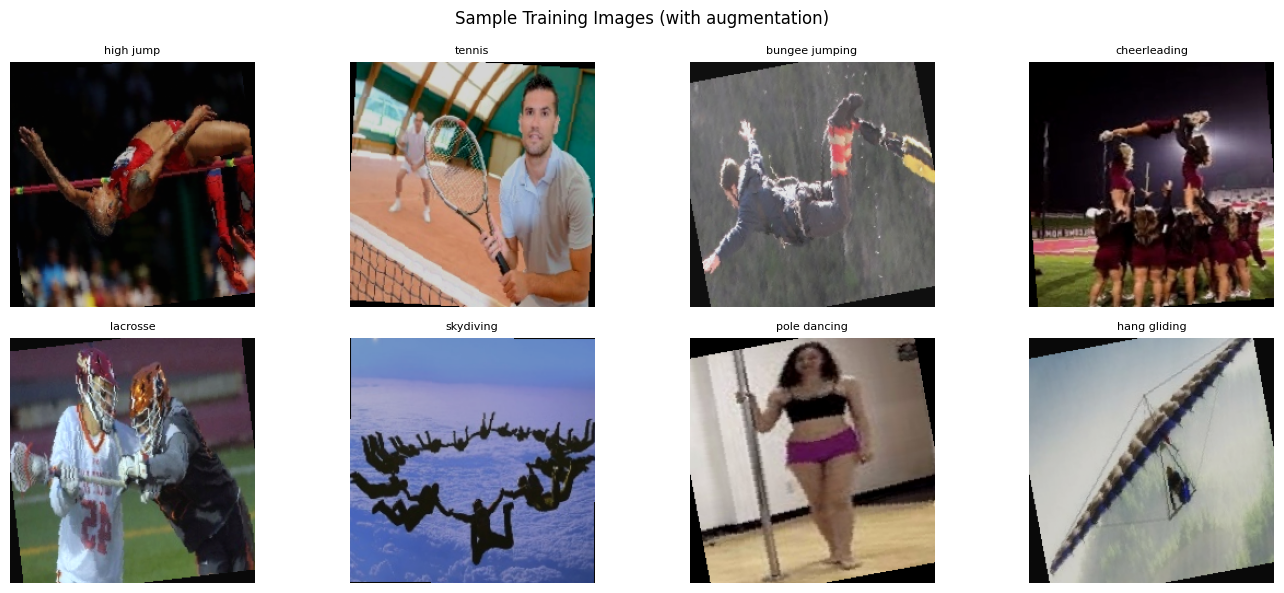

In [5]:
def imshow_batch(loader, n=8):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    # Denormalize
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = imgs * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for ax, img, lbl in zip(axes.flat, imgs, labels):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(class_names[lbl.item()], fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Training Images (with augmentation)', fontsize=12)
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader)

In [6]:
# Load EfficientNet-B0 with latest ImageNet weights
weights    = EfficientNet_B0_Weights.IMAGENET1K_V1
base_model = models.efficientnet_b0(weights=weights)

# Freeze all base parameters (Phase 1)
for param in base_model.parameters():
    param.requires_grad = False

print('Base model loaded and frozen.')
print(f'Total params      : {sum(p.numel() for p in base_model.parameters()):,}')
print(f'Trainable params  : {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.8MB/s]

Base model loaded and frozen.
Total params      : 5,288,548
Trainable params  : 0


In [8]:
# Get the number of features going into the original classifier
in_features = base_model.classifier[1].in_features
print(f'Classifier input features: {in_features}')

def build_classifier_head(in_features, num_classes, dropout):
    """
    Build an upgraded 3-layer classifier head with BatchNorm.
    
    Architecture: 1280 → 1024 → 512 → NUM_CLASSES
    - BatchNorm after each hidden linear layer for training stability
    - Graduated dropout: higher at input, lower between hidden layers
    - This is significantly more expressive than the previous 2-layer head
    """
    return nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout * 0.5),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout * 0.5),
        nn.Linear(512, num_classes)
    )

# Replace with upgraded head
base_model.classifier = build_classifier_head(in_features, NUM_CLASSES, DROPOUT)

model = base_model.to(device)

# Verify only classifier is trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Total params           : {total:,}')
print(f'Trainable params (head): {trainable:,}')
print(f'Head architecture:')
print(model.classifier)

Classifier input features: 1280
Total params           : 5,898,464
Trainable params (head): 1,890,916
Head architecture:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=1024, bias=True)
  (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Dropout(p=0.15, inplace=False)
  (5): Linear(in_features=1024, out_features=512, bias=True)
  (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU(inplace=True)
  (8): Dropout(p=0.15, inplace=False)
  (9): Linear(in_features=512, out_features=100, bias=True)
)


In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct  += preds.eq(labels).sum().item()
            total    += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, valid_loader, optimizer,
                scheduler, criterion, epochs, phase_name):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_acc   = 0.0
    best_state = None
    patience_count = 0
    PATIENCE = 5

    print(f'\n{"="*55}')
    print(f'  {phase_name}')
    print(f'{"="*55}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader,
                                                criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, valid_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f'Epoch {epoch:02d}/{epochs}  '
              f'loss: {train_loss:.4f}  acc: {train_acc:.4f}  '
              f'val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}  '
              f'({elapsed:.0f}s)')

        # Save best model
        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, SAVE_PATH)
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_state)
    print(f'Best val accuracy: {best_acc:.4f}')
    return model, history

In [13]:
# ─── Hyperparameter Ablation ─────────────────────────────────
# Sweep one hyperparameter at a time using short Phase-1-only runs
# to determine which value works best for each parameter.

def build_fresh_model(dropout):
    #Create a fresh EfficientNet-B0 with frozen base and new head.
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    m = models.efficientnet_b0(weights=weights)
    for param in m.parameters():
        param.requires_grad = False
    m.classifier = build_classifier_head(
        m.classifier[1].in_features, NUM_CLASSES, dropout
    )
    return m.to(device)

def run_single_ablation(lr_head, dropout, weight_decay, label_smoothing, epochs):
    #Run a short Phase-1-only training and return best val accuracy
    m = build_fresh_model(dropout)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.Adam(m.classifier.parameters(),
                           lr=lr_head, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)
    
    best_acc = 0.0
    for epoch in range(1, epochs + 1):
        # Train
        m.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(m(imgs), labels)
            loss.backward()
            optimizer.step()
        # Eval
        val_loss, val_acc = evaluate(m, valid_loader, criterion)
        scheduler.step(val_loss)
        if val_acc > best_acc:
            best_acc = val_acc
    
    del m  # free memory
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return best_acc

# ─── Run ablation sweeps ─────────────────────────────────────
ablation_results = {}

# Default values for baseline
defaults = {
    'lr_head': LR_HEAD,
    'dropout': DROPOUT,
    'weight_decay': WEIGHT_DECAY,
    'label_smoothing': LABEL_SMOOTHING
}

sweeps = [
    ('lr_head',         ABLATION_LR_HEAD),
    ('dropout',         ABLATION_DROPOUT),
    ('weight_decay',    ABLATION_WEIGHT_DECAY),
    ('label_smoothing', ABLATION_LABEL_SMOOTH),
]

print(f'{"="*65}')
print(f'  HYPERPARAMETER ABLATION ({ABLATION_EPOCHS} epochs per run)')
print(f'{"="*65}')
print(f'  Defaults: {defaults}')
print()

for param_name, param_list in sweeps:
    print(f'\\n--- Sweeping: {param_name} ---')
    ablation_results[param_name] = {}
    
    for val in param_list:
        # Build config: defaults + override current param
        cfg = dict(defaults)
        cfg[param_name] = val
        
        t0 = time.time()
        acc = run_single_ablation(
            lr_head=cfg['lr_head'],
            dropout=cfg['dropout'],
            weight_decay=cfg['weight_decay'],
            label_smoothing=cfg['label_smoothing'],
            epochs=ABLATION_EPOCHS
        )
        elapsed = time.time() - t0
        ablation_results[param_name][val] = acc
        marker = ' ◀ default' if val == defaults[param_name] else ''
        print(f'  {param_name}={val:<10}  val_acc={acc:.4f}  ({elapsed:.0f}s){marker}')

# ─── Select best value for each parameter ─────────────────────
best_params = dict(defaults)
print(f'\\n{"="*65}')
print(f'  ABLATION SUMMARY')
print(f'{"="*65}')
for param_name in ablation_results:
    results = ablation_results[param_name]
    best_val = max(results, key=results.get)
    best_acc = results[best_val]
    best_params[param_name] = best_val
    print(f'  {param_name:20s} -> best={best_val}  (val_acc={best_acc:.4f})')

print(f'\\n  Final best hyperparameters: {best_params}')

# Store for use in subsequent cells
BEST_LR_HEAD        = best_params['lr_head']
BEST_DROPOUT        = best_params['dropout']
BEST_WEIGHT_DECAY   = best_params['weight_decay']
BEST_LABEL_SMOOTH   = best_params['label_smoothing']
print(f'\\n  These will be used for full training in Phase 1 & 2.')

  HYPERPARAMETER ABLATION (5 epochs per run)
  Defaults: {'lr_head': 0.001, 'dropout': 0.3, 'weight_decay': 0.0001, 'label_smoothing': 0.1}

\n--- Sweeping: lr_head ---
  lr_head=0.001       val_acc=0.8620  (302s) ◀ default
  lr_head=0.0005      val_acc=0.8520  (251s)
  lr_head=0.0001      val_acc=0.8480  (247s)
\n--- Sweeping: dropout ---
  dropout=0.2         val_acc=0.8580  (249s)
  dropout=0.3         val_acc=0.8540  (244s) ◀ default
  dropout=0.4         val_acc=0.8440  (239s)
\n--- Sweeping: weight_decay ---
  weight_decay=0.0001      val_acc=0.8680  (251s) ◀ default
  weight_decay=0.001       val_acc=0.8420  (246s)
  weight_decay=1e-05       val_acc=0.8640  (247s)
\n--- Sweeping: label_smoothing ---
  label_smoothing=0.0         val_acc=0.8540  (243s)
  label_smoothing=0.1         val_acc=0.8560  (241s) ◀ default
  label_smoothing=0.2         val_acc=0.8520  (242s)
\n=================================================================
  ABLATION SUMMARY
  lr_head              -> be

In [14]:
# ─── Phase 1: Head Training (using best ablation hyperparameters) ───
# Rebuild the model fresh with the best dropout from ablation
model = build_fresh_model(BEST_DROPOUT)

criterion = nn.CrossEntropyLoss(label_smoothing=BEST_LABEL_SMOOTH)

# Only pass classifier params to optimizer (base is frozen)
optimizer1 = optim.Adam(model.classifier.parameters(),
                        lr=BEST_LR_HEAD, weight_decay=BEST_WEIGHT_DECAY)
scheduler1 = ReduceLROnPlateau(optimizer1, mode='min',
                               factor=0.3, patience=2)

print(f'Using ablation-tuned hyperparameters:')
print(f'  LR_HEAD       = {BEST_LR_HEAD}')
print(f'  DROPOUT       = {BEST_DROPOUT}')
print(f'  WEIGHT_DECAY  = {BEST_WEIGHT_DECAY}')
print(f'  LABEL_SMOOTH  = {BEST_LABEL_SMOOTH}')

model, history1 = train_model(
    model, train_loader, valid_loader,
    optimizer1, scheduler1, criterion,
    epochs=EPOCHS_HEAD,
    phase_name='PHASE 1 — Head Training (base frozen, ablation-tuned)'
)

Using ablation-tuned hyperparameters:
  LR_HEAD       = 0.001
  DROPOUT       = 0.2
  WEIGHT_DECAY  = 0.0001
  LABEL_SMOOTH  = 0.1

  PHASE 1 — Head Training (base frozen, ablation-tuned)
Epoch 01/20  loss: 2.4226  acc: 0.5387  val_loss: 1.5972  val_acc: 0.7680  (50s)
Epoch 02/20  loss: 1.8148  acc: 0.7000  val_loss: 1.4501  val_acc: 0.8160  (51s)
Epoch 03/20  loss: 1.6848  acc: 0.7445  val_loss: 1.4031  val_acc: 0.8540  (51s)
Epoch 04/20  loss: 1.6144  acc: 0.7660  val_loss: 1.3898  val_acc: 0.8600  (51s)
Epoch 05/20  loss: 1.5759  acc: 0.7756  val_loss: 1.3851  val_acc: 0.8480  (51s)
Epoch 06/20  loss: 1.5353  acc: 0.7902  val_loss: 1.3928  val_acc: 0.8420  (50s)
Epoch 07/20  loss: 1.4896  acc: 0.8071  val_loss: 1.3772  val_acc: 0.8380  (49s)
Epoch 08/20  loss: 1.4766  acc: 0.8117  val_loss: 1.3381  val_acc: 0.8740  (48s)
Epoch 09/20  loss: 1.4630  acc: 0.8184  val_loss: 1.3556  val_acc: 0.8560  (49s)
Epoch 10/20  loss: 1.4279  acc: 0.8319  val_loss: 1.3662  val_acc: 0.8360  (49s)
Ep

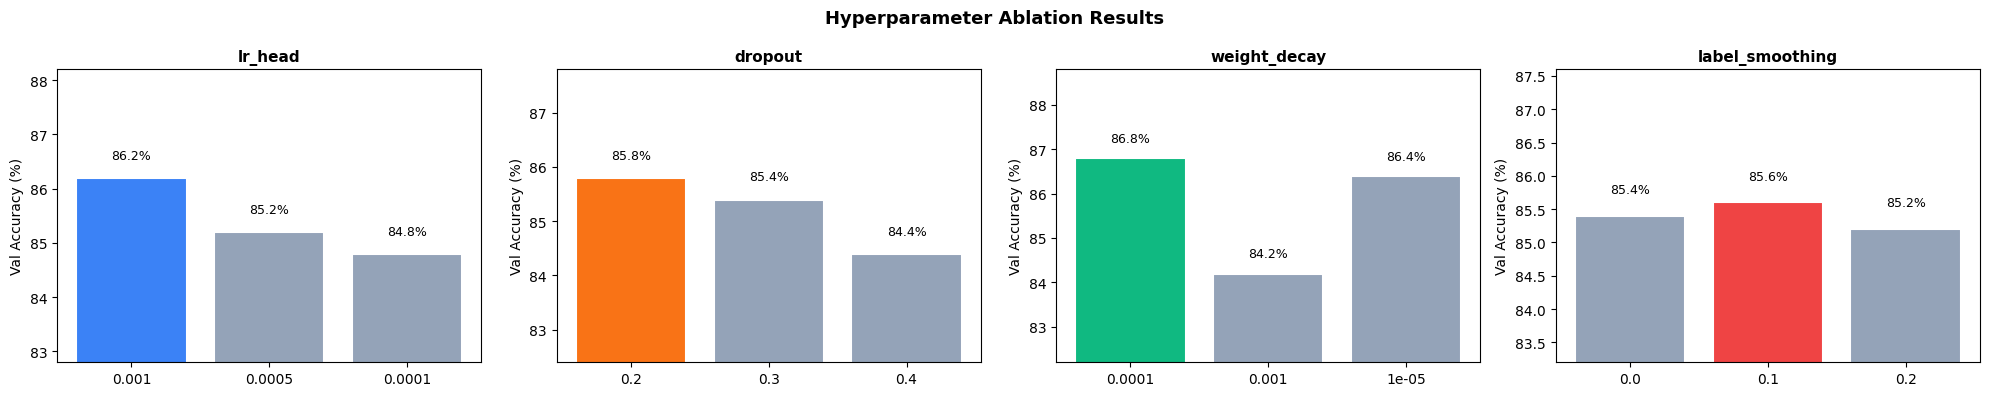

\nLR_FINE ablation results:


NameError: name 'lr_fine_results' is not defined

In [16]:
# ─── Ablation Results Visualization ───────────────────────────
fig, axes = plt.subplots(1, len(ablation_results), figsize=(5*len(ablation_results), 4))
if len(ablation_results) == 1:
    axes = [axes]

colors = ['#3b82f6', '#f97316', '#10b981', '#ef4444', '#8b5cf6']
for idx, (param_name, results) in enumerate(ablation_results.items()):
    ax = axes[idx]
    vals = list(results.keys())
    accs = [results[v] * 100 for v in vals]
    labels = [str(v) for v in vals]
    best_idx = accs.index(max(accs))
    
    bar_colors = ['#94a3b8'] * len(vals)
    bar_colors[best_idx] = colors[idx % len(colors)]
    
    bars = ax.bar(labels, accs, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{param_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Val Accuracy (%)')
    ax.set_ylim(min(accs) - 2, max(accs) + 2)
    
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Hyperparameter Ablation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Also add LR_FINE results
print('\\nLR_FINE ablation results:')
for lr_val, acc in lr_fine_results.items():
    marker = ' ◀ BEST' if lr_val == BEST_LR_FINE else ''
    print(f'  LR_FINE={lr_val:<10}  val_acc={acc*100:.2f}%{marker}')

print(f'\\n{"="*55}')
print(f'  FINAL BEST HYPERPARAMETERS')
print(f'{"="*55}')
print(f'  LR_HEAD        = {BEST_LR_HEAD}')
print(f'  LR_FINE        = {BEST_LR_FINE}')
print(f'  DROPOUT        = {BEST_DROPOUT}')
print(f'  WEIGHT_DECAY   = {BEST_WEIGHT_DECAY}')
print(f'  LABEL_SMOOTH   = {BEST_LABEL_SMOOTH}')

In [17]:
# Unfreeze every layer in the model
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable params after unfreeze: {trainable:,}')

# Determine best LR_FINE via ablation results
# We use the ABLATION_LR_FINE list with a quick sweep here too
print(f'\\n--- Quick LR_FINE sweep for Phase 2 ---')
lr_fine_results = {}
for lr_fine_val in ABLATION_LR_FINE:
    # Test each LR_FINE with 2-epoch micro-run on the CURRENT unfrozen model
    # We do a lightweight evaluation approach: just measure 1 epoch val_acc
    test_model = copy.deepcopy(model)
    for p in test_model.parameters():
        p.requires_grad = True
    opt_test = optim.Adam([
        {'params': test_model.features.parameters(), 'lr': lr_fine_val},
        {'params': test_model.classifier.parameters(), 'lr': lr_fine_val * 10}
    ], weight_decay=BEST_WEIGHT_DECAY)
    crit_test = nn.CrossEntropyLoss(label_smoothing=BEST_LABEL_SMOOTH)
    
    test_model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        opt_test.zero_grad()
        loss = crit_test(test_model(imgs), labels)
        loss.backward()
        opt_test.step()
    
    _, val_acc = evaluate(test_model, valid_loader, crit_test)
    lr_fine_results[lr_fine_val] = val_acc
    print(f'  LR_FINE={lr_fine_val:<10}  val_acc={val_acc:.4f}')
    del test_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

BEST_LR_FINE = max(lr_fine_results, key=lr_fine_results.get)
print(f'  Best LR_FINE: {BEST_LR_FINE}')

# Differential LRs: lower for base, 10x higher for head
optimizer2 = optim.Adam([
    {'params': model.features.parameters(),   'lr': BEST_LR_FINE},
    {'params': model.classifier.parameters(), 'lr': BEST_LR_FINE * 10}
], weight_decay=BEST_WEIGHT_DECAY)

scheduler2 = ReduceLROnPlateau(optimizer2, mode='min',
                               factor=0.3, patience=3)

model, history2 = train_model(
    model, train_loader, valid_loader,
    optimizer2, scheduler2, criterion,
    epochs=EPOCHS_FINE,
    phase_name='PHASE 2 — Full Fine-Tuning (ablation-tuned)'
)


Total trainable params after unfreeze: 5,898,464
\n--- Quick LR_FINE sweep for Phase 2 ---
  LR_FINE=1e-05       val_acc=0.8860
  LR_FINE=5e-05       val_acc=0.9060
  LR_FINE=0.0001      val_acc=0.9220
  Best LR_FINE: 0.0001

  PHASE 2 — Full Fine-Tuning (ablation-tuned)
Epoch 01/20  loss: 1.3251  acc: 0.8600  val_loss: 1.1678  val_acc: 0.9260  (70s)
Epoch 02/20  loss: 1.1515  acc: 0.9253  val_loss: 1.0988  val_acc: 0.9380  (70s)
Epoch 03/20  loss: 1.0817  acc: 0.9472  val_loss: 1.0710  val_acc: 0.9420  (70s)
Epoch 04/20  loss: 1.0327  acc: 0.9623  val_loss: 1.0326  val_acc: 0.9560  (70s)
Epoch 05/20  loss: 1.0075  acc: 0.9681  val_loss: 1.0164  val_acc: 0.9600  (70s)
Epoch 06/20  loss: 0.9909  acc: 0.9719  val_loss: 1.0123  val_acc: 0.9660  (70s)
Epoch 07/20  loss: 0.9673  acc: 0.9778  val_loss: 1.0182  val_acc: 0.9560  (70s)
Epoch 08/20  loss: 0.9534  acc: 0.9801  val_loss: 0.9931  val_acc: 0.9640  (70s)
Epoch 09/20  loss: 0.9492  acc: 0.9804  val_loss: 0.9822  val_acc: 0.9600  (70s)

In [18]:
# Load the best saved checkpoint
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')

# Per-class accuracy with sklearn
from sklearn.metrics import classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\nClassification Report (first 20 classes):')
print(classification_report(
    all_labels, all_preds, target_names=class_names, zero_division=0
)[:3000])

Test Loss     : 0.9582
Test Accuracy : 96.60%

Classification Report (first 20 classes):
                       precision    recall  f1-score   support

           air hockey       1.00      1.00      1.00         5
      ampute football       1.00      1.00      1.00         5
              archery       1.00      1.00      1.00         5
        arm wrestling       1.00      1.00      1.00         5
         axe throwing       1.00      1.00      1.00         5
         balance beam       0.83      1.00      0.91         5
        barell racing       1.00      1.00      1.00         5
             baseball       1.00      1.00      1.00         5
           basketball       1.00      1.00      1.00         5
       baton twirling       1.00      1.00      1.00         5
            bike polo       1.00      1.00      1.00         5
            billiards       1.00      1.00      1.00         5
                  bmx       1.00      0.80      0.89         5
              bobsled       

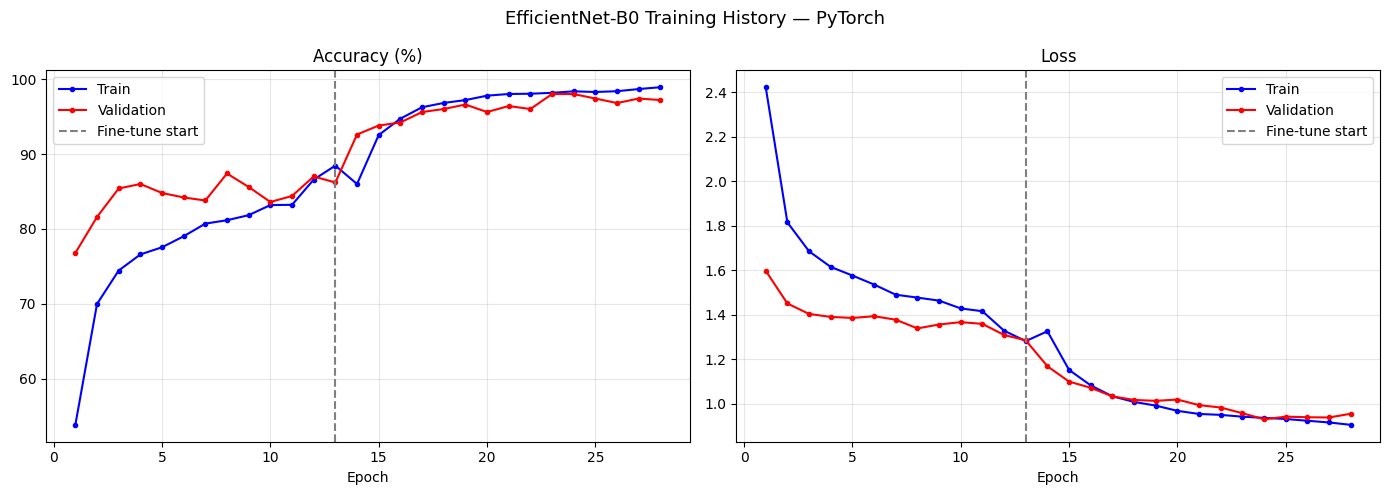

In [19]:
def plot_combined_history(h1, h2):
    acc  = h1['train_acc']  + h2['train_acc']
    val  = h1['val_acc']    + h2['val_acc']
    loss = h1['train_loss'] + h2['train_loss']
    vloss= h1['val_loss']   + h2['val_loss']
    ep   = range(1, len(acc) + 1)
    split= len(h1['train_acc'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, [a*100 for a in acc],  'b-o', markersize=3, label='Train')
    ax1.plot(ep, [a*100 for a in val],  'r-o', markersize=3, label='Validation')
    ax1.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy (%)', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, loss,  'b-o', markersize=3, label='Train')
    ax2.plot(ep, vloss, 'r-o', markersize=3, label='Validation')
    ax2.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('EfficientNet-B0 Training History — PyTorch', fontsize=13)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_history(history1, history2)

In [20]:
# Save full model checkpoint with metadata
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'class_to_idx'     : train_dataset.class_to_idx,
    'idx_to_class'     : idx_to_class,
    'num_classes'      : NUM_CLASSES,
    'img_size'         : IMG_SIZE,
}
torch.save(checkpoint, '/kaggle/working/sports_efficientnet_b0_pytorch.pth')
print('Checkpoint saved!')

# Also save class names as JSON
with open('/kaggle/working/class_indices.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)

for fname in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{fname}') / 1e6
    print(f'  {fname:<45} {size:.1f} MB')

Checkpoint saved!
  class_indices.json                            0.0 MB
  sports_efficientnet_b0_pytorch.pth            23.9 MB
  state.db                                      1.3 MB
  ablation_results.png                          0.1 MB
  best_model.pth                                23.9 MB
  training_history.png                          0.1 MB
  .virtual_documents                            0.0 MB


In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from PIL import Image
import io, torch
from torchvision import transforms

# ── Inference transform (same as val/test) ──────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def predict_from_bytes(img_bytes, model, idx_to_class, top_k=5):
    """Run inference on raw image bytes and return top-k predictions."""
    model.eval()
    img    = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    tensor = infer_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs     = torch.softmax(model(tensor), dim=1)[0]
        top_probs, top_idxs = probs.topk(top_k)
    return img, [(idx_to_class[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]

# ── Widget UI ───────────────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.webp',
    multiple=False,
    description='Upload Image',
    button_style='info',
    layout=widgets.Layout(width='200px')
)
out = widgets.Output()

def on_upload(change):
    with out:
        clear_output(wait=True)
        # ipywidgets >= 8.x: .value is a tuple of dicts
        uploaded  = upload_btn.value[0]
        img_bytes = uploaded['content']

        img, predictions = predict_from_bytes(img_bytes, model, idx_to_class, top_k=5)

        # ── Display image + bar chart side by side ──────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        ax1.imshow(img)
        ax1.set_title(f'Uploaded: {uploaded["name"]}', fontsize=10)
        ax1.axis('off')

        sports = [p[0].replace('_', ' ').title() for p in predictions]
        probs  = [p[1] * 100 for p in predictions]
        colors = ['#f97316' if i == 0 else '#94a3b8' for i in range(len(sports))]

        bars = ax2.barh(sports[::-1], probs[::-1], color=colors[::-1], height=0.55)
        ax2.set_xlabel('Confidence (%)')
        ax2.set_title('Top-5 Predictions', fontsize=11)
        ax2.set_xlim(0, 100)
        for bar, prob in zip(bars, probs[::-1]):
            ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob:.1f}%', va='center', fontsize=9)
        ax2.spines[['top','right']].set_visible(False)

        plt.suptitle(f'Prediction: {predictions[0][0].replace("_"," ").title()}  '
                     f'({predictions[0][1]*100:.1f}% confidence)',
                     fontsize=12, fontweight='bold', color='#f97316')
        plt.tight_layout()
        plt.show()

upload_btn.observe(on_upload, names='value')
display(widgets.VBox([
    widgets.Label('Select a sports image to classify:'),
    upload_btn,
    out
]))